In [11]:
import os, sys, time, math
import numpy as np
import torch
import matplotlib.pyplot as plt

# The file list shows model.py is directly in /content/
project_root = '/content'

sys.path.insert(0, project_root)
print('Project root:', project_root)

import model
from model import GPT, GPTConfig
print('Loaded successfully!')

Project root: /content
Loaded successfully!


### Device Configuration

In [12]:
device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = 'mps'
print(f"Using device: {device}")

Using device: cuda


### Data Loader setup
We define a function to grab a batch of data from the memory-mapped `.bin` files created during the dataset preparation phase.

In [13]:
batch_size = 32 # number of independent sequences to process in parallel
block_size = 256 # maximum context length for predictions

def get_batch(split, dataset='poems'):
    # The files are directly in /content/ as {dataset}_{split}.bin
    data_dir = '/content'
    filename = f"{dataset}_{split}.bin"
    filepath = os.path.join(data_dir, filename)

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Dataset file {filepath} not found.")

    data = np.memmap(filepath, dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])

    if device == 'cuda':
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y

### Model Initialization
We initialize a smaller GPT configuration (4 layers, 4 heads, 256 dim) for faster training.

In [14]:
from model import GPT, GPTConfig

# Reducing n_embd to 64 aggressively reduces the FFN size (4 * 64)
# and the overall model capacity.
config = GPTConfig(
    block_size=block_size,
    vocab_size=50257,
    n_layer=4,
    n_head=4,
    n_embd=32,
    dropout=0.1
)

model = GPT(config)
model.to(device)
print(f"Model parameters: {model.get_num_params()/1e6:.2f} M")

number of parameters: 1.66M
Model parameters: 1.66 M


### Training Loop & Tracker

In [15]:
def estimate_loss(model, dataset='poems', eval_iters=50):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split, dataset)
            with torch.no_grad():
                logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

def get_gpu_memory():
    if device == 'cuda':
        return torch.cuda.memory_allocated() / (1024**2) # MB
    elif device == 'mps':
        return torch.mps.current_allocated_memory() / (1024**2) # MB
    return 0.0

In [16]:
def train_model(model, dataset, max_iters=2000, eval_interval=200, learning_rate=1e-3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    # Trackers
    history = {
        'iter': [],
        'train_loss': [],
        'val_loss': [],
        'gpu_mem_mb': [],
        'time_sec': []
    }

    start_time = time.time()
    print(f"\n--- Starting {dataset.upper()} training ---")

    for iter in range(max_iters):
        # Every once in a while evaluate the loss on train and val sets
        if iter % eval_interval == 0 or iter == max_iters - 1:
            losses = estimate_loss(model, dataset)
            gpu_mem = get_gpu_memory()
            elapsed = time.time() - start_time

            history['iter'].append(iter)
            history['train_loss'].append(losses['train'])
            history['val_loss'].append(losses['val'])
            history['gpu_mem_mb'].append(gpu_mem)
            history['time_sec'].append(elapsed)

            print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f} | GPU Mem: {gpu_mem:.1f} MB | Time: {elapsed:.1f}s")

        # Sample a batch of data
        xb, yb = get_batch('train', dataset)

        # Evaluate the loss
        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    return history

### Phase 1: Pretraining on Poems
First, we will build a base understanding of the language structure.

In [17]:
poem_history = train_model(model, dataset='poems', max_iters=2000, eval_interval=250, learning_rate=1e-3)


--- Starting POEMS training ---
step 0: train loss 10.8265, val loss 10.8271 | GPU Mem: 88.1 MB | Time: 4.6s
step 250: train loss 6.6364, val loss 6.7748 | GPU Mem: 1677.8 MB | Time: 37.5s
step 500: train loss 6.0118, val loss 6.2322 | GPU Mem: 1677.8 MB | Time: 70.0s
step 750: train loss 5.6711, val loss 5.9696 | GPU Mem: 1677.8 MB | Time: 102.6s
step 1000: train loss 5.5592, val loss 5.8171 | GPU Mem: 1677.8 MB | Time: 135.3s
step 1250: train loss 5.4332, val loss 5.7211 | GPU Mem: 1677.8 MB | Time: 167.8s
step 1500: train loss 5.3943, val loss 5.6565 | GPU Mem: 1677.8 MB | Time: 200.4s
step 1750: train loss 5.3285, val loss 5.6078 | GPU Mem: 1677.8 MB | Time: 233.1s
step 1999: train loss 5.2774, val loss 5.5715 | GPU Mem: 1677.8 MB | Time: 265.6s


### Phase 2: Fine-Tuning on Raps
Next, we use a slightly lower learning rate to fine-tune the model to match conditioned rap styles.

In [18]:
rap_history = train_model(model, dataset='raps', max_iters=2000, eval_interval=250, learning_rate=3e-4)


--- Starting RAPS training ---
step 0: train loss 6.0480, val loss 6.0882 | GPU Mem: 94.4 MB | Time: 4.7s
step 250: train loss 5.0879, val loss 5.3072 | GPU Mem: 1677.8 MB | Time: 37.3s
step 500: train loss 4.8702, val loss 5.1591 | GPU Mem: 1677.8 MB | Time: 69.9s
step 750: train loss 4.6686, val loss 5.0539 | GPU Mem: 1677.8 MB | Time: 102.5s
step 1000: train loss 4.6293, val loss 5.0140 | GPU Mem: 1677.8 MB | Time: 135.1s
step 1250: train loss 4.6087, val loss 5.0029 | GPU Mem: 1677.8 MB | Time: 167.7s
step 1500: train loss 4.4865, val loss 4.9397 | GPU Mem: 1677.8 MB | Time: 200.3s
step 1750: train loss 4.4924, val loss 4.9649 | GPU Mem: 1677.8 MB | Time: 232.9s
step 1999: train loss 4.4438, val loss 4.9470 | GPU Mem: 1677.8 MB | Time: 265.4s


### Visualization of Training Progress

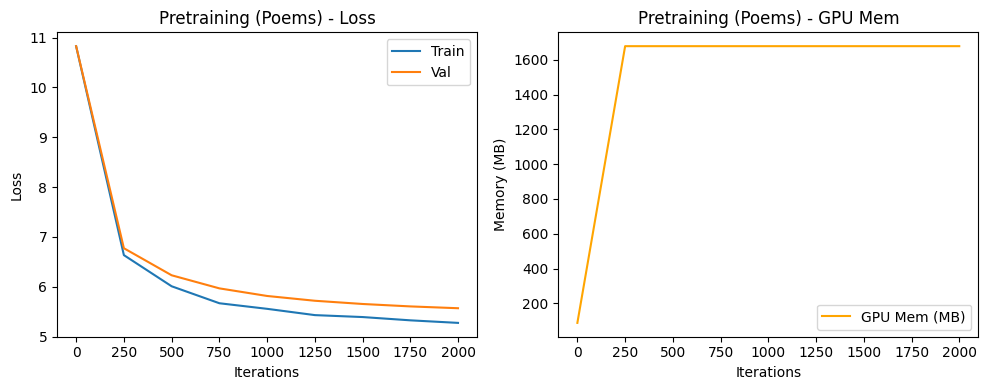

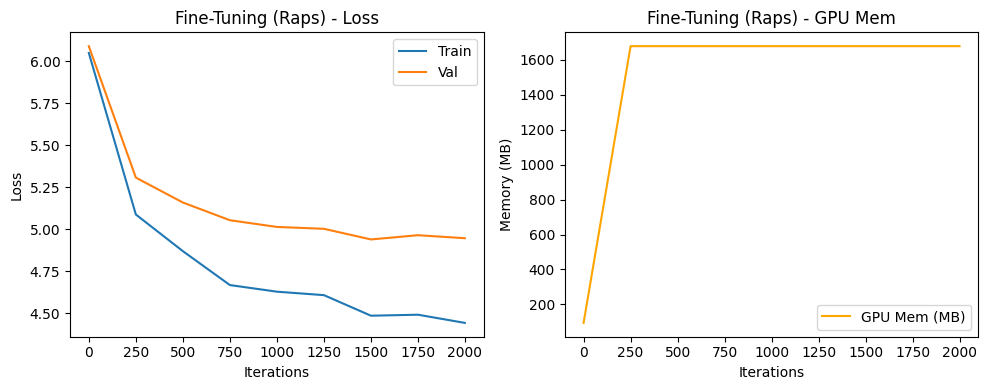

In [19]:
def plot_history(history, title):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['iter'], history['train_loss'], label='Train')
    plt.plot(history['iter'], history['val_loss'], label='Val')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['iter'], history['gpu_mem_mb'], label='GPU Mem (MB)', color='orange')
    plt.xlabel('Iterations')
    plt.ylabel('Memory (MB)')
    plt.title(f"{title} - GPU Mem")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(poem_history, "Pretraining (Poems)")
plot_history(rap_history, "Fine-Tuning (Raps)")

### Save the Model
After training, we save the model state and the configuration to a file.

In [20]:
checkpoint = {
    'model': model.state_dict(),
    'config': config,
}
torch.save(checkpoint, 'nanogpt_checkpoint.pt')
print("Model saved to nanogpt_checkpoint.pt")

Model saved to nanogpt_checkpoint.pt
